In [2]:
%%capture
from langchain.chat_models import init_chat_model
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

from dotenv import load_dotenv
load_dotenv()

In [7]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

Simple tool generator

In [3]:
@tool
def get_stock_price(symbol: str) -> float:
    '''Mock implementation returning hardcoded stock prices for demonstration purposes.
    In a real-world scenario, this function would fetch data from a financial API.
    :param symbol: stock symbol
    :return: current price of the stock
    '''

    return {
        "MSFT": 200.3,
        "AAPL": 100.4,
        "AMZN": 150.0,
        "RIL": 87.6
    }.get(symbol, 0.0)

tools = [get_stock_price]

In [4]:

llm = init_chat_model("google_genai:gemini-2.0-flash")

#This is how you bind tools to LLM instances in LangGraph
llm_with_tools = llm.bind_tools(tools)

In [5]:
def chatbot(state: State):
    '''A simple chatbot function that uses an LLM with tool capabilities
    to process messages in the state.
    :param state: current state of graph containing messages
    :return: updated state with new messages'''
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


In [8]:
builder = StateGraph(State)

#lets add nodes first
builder.add_node(chatbot)
builder.add_node("tools", ToolNode(tools))

#now lets add edges and relations
builder.add_edge(START, "chatbot")
#add conditional edge to tools node (so we don't want to call tools every time, just when needed)
builder.add_conditional_edges("chatbot", tools_condition)

graph = builder.compile()

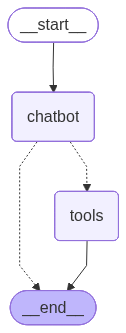

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
state = graph.invoke(
    {"messages": [
        {
            "role": "user",
            "content": "What is the price of AAPL stock right now?"
        }
    ]})

print(state["messages"][-1].content)
print(state["messages"])

100.4
[HumanMessage(content='What is the price of AAPL stock right now?', additional_kwargs={}, response_metadata={}, id='62af2046-ea75-4a29-a3b3-5a1d551a9803'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_stock_price', 'arguments': '{"symbol": "AAPL"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019b0fb1-8f68-78f3-90e0-58d6aaa8d167-0', tool_calls=[{'name': 'get_stock_price', 'args': {'symbol': 'AAPL'}, 'id': 'e194c2e0-436b-4a9e-8391-24a3d73cb981', 'type': 'tool_call'}], usage_metadata={'input_tokens': 65, 'output_tokens': 7, 'total_tokens': 72, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='100.4', name='get_stock_price', id='3f4f3744-4a54-451e-90cf-c7533e41df7b', tool_call_id='e194c2e0-436b-4a9e-8391-24a3d73cb981')]


In [11]:
state = graph.invoke(
    {"messages": [
        {
            "role": "user",
            "content": "What is the prices of AMZN and  RIL stock right now?, please provide the answer in a json format with stock symbols as keys and their prices as values."
        }
    ]})

print(state["messages"][-1].content)
print(state["messages"])

```json
{
  "AMZN": 130.0,
  "RIL": 2500.0
}
```
[HumanMessage(content='What is the prices of AMZN and  RIL stock right now?, please provide the answer in a json format with stock symbols as keys and their prices as values.', additional_kwargs={}, response_metadata={}, id='afe7fd19-0bbc-48b5-b9a4-4cdf810cce34'), AIMessage(content='```json\n{\n  "AMZN": 130.0,\n  "RIL": 2500.0\n}\n```', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019b0fb2-3d7d-71a2-9126-b2c8a7ee3314-0', usage_metadata={'input_tokens': 88, 'output_tokens': 34, 'total_tokens': 122, 'input_token_details': {'cache_read': 0}})]


In [12]:
msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost? do you recomand RIL instead of MSFT?"

state = graph.invoke(
    {
        "messages": [
            {
                "role": "user", 
                "content": msg
            }
        ]})

print(state["messages"][-1].content)

200.3
